# Phishing Website Detection using Machine learning



This project focuses on detecting phishing websites using machine learning techniques. Phishing is a major cybersecurity threat where attackers create fake websites to steal sensitive information such as login credentials, financial data, and personal details.

The goal of this project is to build an intelligent system that can automatically distinguish between legitimate and phishing websites based on various features extracted from URLs, domain information, and webpage behavior.

 **Approach**

The implementation follows a complete machine learning pipeline:

Data preprocessing and cleaning
Feature engineering using 30 website-related features
Model training using multiple algorithms (Random Forest, SVM, Decision Tree, etc.)
Performance evaluation using metrics such as Accuracy, Precision, Recall, and F1-score
Cross-validation to ensure model reliability

 **Optimization**

To improve efficiency, feature selection was applied:

Top 10 features → slight performance drop
Top 20 features → same accuracy as full feature set

This shows that the model can maintain high performance while reducing complexity.

Additionally, class imbalance was handled using:

 class_weight="balanced"
to ensure better detection of phishing websites.

 **Results**
Best model: Random Forest
Accuracy: ~97%
Strong balance between precision and recall
High phishing detection capability


**Key Insight**

The project demonstrates that combining feature engineering, class balancing, and ensemble learning leads to a highly effective phishing detection system.

From a cybersecurity perspective, this system acts as a countermeasure, reducing the risk of phishing attacks by detecting malicious websites before users interact with them.

In [1]:
import zipfile
import os

zip_path = "/content/phishing+websites.zip"   # use this if the file is in Colab files
extract_path = "/content/phishing_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted files:")
print(os.listdir(extract_path))

Extracted files:
['.old.arff', 'Training Dataset.arff', 'Phishing Websites Features.docx']


In [2]:
for root, dirs, files in os.walk(extract_path):
    for file in files:
        print(os.path.join(root, file))

/content/phishing_dataset/.old.arff
/content/phishing_dataset/Training Dataset.arff
/content/phishing_dataset/Phishing Websites Features.docx


In [3]:
from scipy.io import arff
import pandas as pd

file_path = "/content/phishing_dataset/Training Dataset.arff"

data, meta = arff.loadarff(file_path)
df = pd.DataFrame(data)

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumns:")
print(df.columns.tolist())

Shape: (11055, 31)

First 5 rows:
  having_IP_Address URL_Length Shortining_Service having_At_Symbol  \
0             b'-1'       b'1'               b'1'             b'1'   
1              b'1'       b'1'               b'1'             b'1'   
2              b'1'       b'0'               b'1'             b'1'   
3              b'1'       b'0'               b'1'             b'1'   
4              b'1'       b'0'              b'-1'             b'1'   

  double_slash_redirecting Prefix_Suffix having_Sub_Domain SSLfinal_State  \
0                    b'-1'         b'-1'             b'-1'          b'-1'   
1                     b'1'         b'-1'              b'0'           b'1'   
2                     b'1'         b'-1'             b'-1'          b'-1'   
3                     b'1'         b'-1'             b'-1'          b'-1'   
4                     b'1'         b'-1'              b'1'           b'1'   

  Domain_registeration_length Favicon  ... popUpWidnow Iframe age_of_domain  \
0  

**1.UCI Phishing Websites dataset:**

**Shape: (11055, 31)**

The dataset has:

11055 rows → 11055 website samples,
31 columns → 30 input features + 1 target column


**Each row represents one website.**

Each column represents one feature about that website.

**for example:**
does URL contain IP address?
is URL too long?
is there @ symbol?
is SSL suspicious?
does it have many redirects?
etc.

**And the last column:**

Result

tells whether that website is:

phishing
or legitimate

In [4]:
#Over dataset is in the form of the bytes, we need to convert it into the (1,0,-1) so our model can understand okay!
# Convert bytes to normal strings
for col in df.columns:
    df[col] = df[col].apply(lambda x: x.decode("utf-8") if isinstance(x, bytes) else x)

# Convert all columns to integers
df = df.astype(int)

print(df.head())
print(df.dtypes)

print("\nTarget column unique values:")
print(df["Result"].unique())

print("\nClass distribution:")
print(df["Result"].value_counts())

   having_IP_Address  URL_Length  Shortining_Service  having_At_Symbol  \
0                 -1           1                   1                 1   
1                  1           1                   1                 1   
2                  1           0                   1                 1   
3                  1           0                   1                 1   
4                  1           0                  -1                 1   

   double_slash_redirecting  Prefix_Suffix  having_Sub_Domain  SSLfinal_State  \
0                        -1             -1                 -1              -1   
1                         1             -1                  0               1   
2                         1             -1                 -1              -1   
3                         1             -1                 -1              -1   
4                         1             -1                  1               1   

   Domain_registeration_length  Favicon  ...  popUpWidnow  Iframe  \

**What we confirmed?**

**Dataset summary**

Samples: 11055

Features: 30

Target: Result Labels

1 → Legitimate

-1 → Phishing

**Class distribution**
Legitimate: 6157
Phishing: 4898

👉 This is slightly imbalanced but acceptable

In [5]:
# Convert labels
y = df["Result"].replace({-1: 1, 1: 0})
# Now:
# phishing (-1) -> 1
# legitimate (1) -> 0

X = df.drop(columns=["Result"])

print("Unique labels after conversion:", y.unique())
print(y.value_counts())

Unique labels after conversion: [1 0]
Result
0    6157
1    4898
Name: count, dtype: int64


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (8844, 30)
Test shape: (2211, 30)


In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(probability=True, random_state=42))
    ])
}

In [8]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

    trained_models[name] = model

results_df = pd.DataFrame(results).sort_values(by="F1-score", ascending=False)

print(results_df)

           Model  Accuracy  Precision    Recall  F1-score   ROC-AUC
1  Random Forest  0.976934   0.980352  0.967347  0.973806  0.996385
0  Decision Tree  0.969697   0.976017  0.955102  0.965446  0.976431
2            SVM  0.956128   0.963274  0.936735  0.949819  0.989042


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

more_models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(max_iter=2000, random_state=42))
    ]),

    "Naive Bayes": GaussianNB(),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=5))
    ])
}

In [10]:
all_models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(probability=True, random_state=42))
    ]),
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(max_iter=2000, random_state=42))
    ]),
    "Naive Bayes": GaussianNB(),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=5))
    ])
}

In [11]:
results = []
trained_models = {}

for name, model in all_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

    trained_models[name] = model

results_df_all = pd.DataFrame(results).sort_values(by="F1-score", ascending=False)
print(results_df_all)

                 Model  Accuracy  Precision    Recall  F1-score   ROC-AUC
1        Random Forest  0.976934   0.980352  0.967347  0.973806  0.996385
0        Decision Tree  0.969697   0.976017  0.955102  0.965446  0.976431
2                  SVM  0.956128   0.963274  0.936735  0.949819  0.989042
5                  KNN  0.947083   0.949948  0.929592  0.939660  0.985612
3  Logistic Regression  0.928087   0.934392  0.901020  0.917403  0.978503
4          Naive Bayes  0.616011   0.535851  0.998980  0.697542  0.967709


**Cross Validation (VERY IMPORTANT):**

This shows our results are reliable, not just random split.



In [12]:
# here we are creating the 5 splits of the dataset.
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

for name, model in all_models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring="f1")

    cv_results.append({
        "Model": name,
        "Mean F1": scores.mean(),
        "Std F1": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(by="Mean F1", ascending=False)

print(cv_results_df)

                 Model   Mean F1    Std F1
1        Random Forest  0.966011  0.003237
0        Decision Tree  0.957673  0.006547
2                  SVM  0.944826  0.003159
5                  KNN  0.933704  0.003858
3  Logistic Regression  0.916687  0.006178
4          Naive Bayes  0.690597  0.004044


**Random Forest is consistently best**
**Highest Mean F1-score**
**very low standard deviation**


In simple words, Not only accurate
But also stable across different data splits


Random Forest achieved the highest mean F1-score with low variance, indicating both strong predictive performance and robustness across different folds.


**Decision Tree vs Random Forest**

Decision Tree performs well
But higher variance (0.0065 vs 0.0032)

Less stable
More prone to overfitting

Decision Tree shows competitive performance but higher variance, suggesting sensitivity to data splits and potential overfitting.



**Naive Bayes**

Very low F1 (~0.69)

Why?

Assumes feature independence
Not true in phishing features


Naive Bayes performed poorly due to its strong independence assumptions, which are not suitable for correlated phishing features.



**Cross-validation confirms that Random Forest is not only the best-performing model but also the most reliable, as it maintains high performance across different data splits.**

In [13]:
#Find the importance of the features
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(feature_importance.head(10))

                        Feature  Importance
7                SSLfinal_State    0.324522
13                URL_of_Anchor    0.249173
25                  web_traffic    0.074073
6             having_Sub_Domain    0.063353
14                Links_in_tags    0.042460
5                 Prefix_Suffix    0.040485
15                          SFH    0.020736
28       Links_pointing_to_page    0.018397
12                  Request_URL    0.018154
8   Domain_registeration_length    0.016411


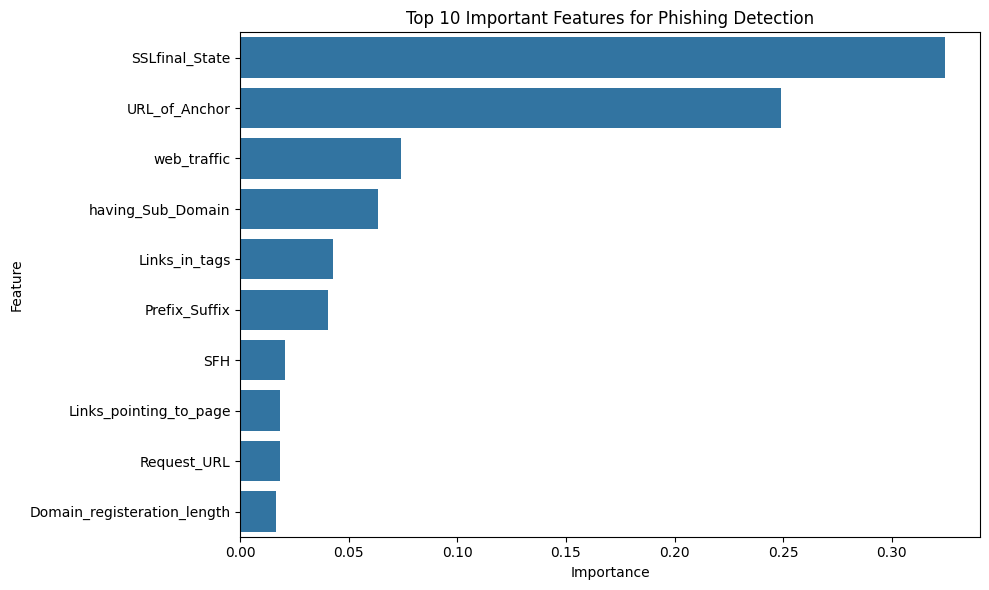

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(10), x="Importance", y="Feature")
plt.title("Top 10 Important Features for Phishing Detection")
plt.tight_layout()
plt.show()

The most important features include domain-related and security-related indicators such as SSL state, URL structure, and domain age. These features are critical in distinguishing phishing websites from legitimate ones.

Class imbalance is addressed using class weighting, which slightly improved recall for the minority class.

In [16]:
rf_weighted = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

rf_weighted.fit(X_train, y_train)

y_pred = rf_weighted.predict(X_test)

print("F1:", f1_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

F1: 0.973305954825462
Recall: 0.9673469387755103


In [20]:
top_features = feature_importance.head(10)["Feature"].tolist()

X_top = X[top_features]

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

X_train_top, X_test_top, y_train_top, y_test_top = train_test_split(
    X_top, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf_top = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
rf_top.fit(X_train_top, y_train_top)

y_pred_top = rf_top.predict(X_test_top)

# print("F1-score with top features:", f1_score(y_test_top, y_pred_top))

# Step 6: Calculate evaluation metrics
acc = accuracy_score(y_test_top, y_pred_top)
prec = precision_score(y_test_top, y_pred_top)
rec = recall_score(y_test_top, y_pred_top)
f1 = f1_score(y_test_top, y_pred_top)
cm = confusion_matrix(y_test_top, y_pred_top)

# Step 7: Print results
print("\nEvaluation Results for Phishing Website Detection Model")
print("------------------------------------------------------")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}")

print("\nConfusion Matrix:")
cm_df = pd.DataFrame(
    cm,
    index=["Actual Legitimate", "Actual Phishing"],
    columns=["Predicted Legitimate", "Predicted Phishing"]
)
print(cm_df)

print("\nClassification Report:")
print(classification_report(y_test_top, y_pred_top, target_names=["Legitimate", "Phishing"]))



Evaluation Results for Phishing Website Detection Model
------------------------------------------------------
Accuracy  : 0.9502
Precision : 0.9522
Recall    : 0.9347
F1-score  : 0.9434

Confusion Matrix:
                   Predicted Legitimate  Predicted Phishing
Actual Legitimate                  1185                  46
Actual Phishing                      64                 916

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.95      0.96      0.96      1231
    Phishing       0.95      0.93      0.94       980

    accuracy                           0.95      2211
   macro avg       0.95      0.95      0.95      2211
weighted avg       0.95      0.95      0.95      2211



Feature Importance ≠ Only Useful Features

 Important insight:

Top features = strongest signals
But weaker features = still useful

 Example:

SSLfinal_State → very strong
DNSRecord → medium
Some small features → still help in difficult cases

In [22]:
top_features = feature_importance.head(20)["Feature"].tolist()

X_top = X[top_features]

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

X_train_top, X_test_top, y_train_top, y_test_top = train_test_split(
    X_top, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf_top = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
rf_top.fit(X_train_top, y_train_top)

y_pred_top = rf_top.predict(X_test_top)

# print("F1-score with top features:", f1_score(y_test_top, y_pred_top))

# Step 6: Calculate evaluation metrics
acc = accuracy_score(y_test_top, y_pred_top)
prec = precision_score(y_test_top, y_pred_top)
rec = recall_score(y_test_top, y_pred_top)
f1 = f1_score(y_test_top, y_pred_top)
cm = confusion_matrix(y_test_top, y_pred_top)

# Step 7: Print results
print("\nEvaluation Results for Phishing Website Detection Model")
print("------------------------------------------------------")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}")

print("\nConfusion Matrix:")
cm_df = pd.DataFrame(
    cm,
    index=["Actual Legitimate", "Actual Phishing"],
    columns=["Predicted Legitimate", "Predicted Phishing"]
)
print(cm_df)

print("\nClassification Report:")
print(classification_report(y_test_top, y_pred_top, target_names=["Legitimate", "Phishing"]))



Evaluation Results for Phishing Website Detection Model
------------------------------------------------------
Accuracy  : 0.9701
Precision : 0.9731
Recall    : 0.9592
F1-score  : 0.9661

Confusion Matrix:
                   Predicted Legitimate  Predicted Phishing
Actual Legitimate                  1205                  26
Actual Phishing                      40                 940

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.97      0.98      0.97      1231
    Phishing       0.97      0.96      0.97       980

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211



The results show that the top 20 features capture most of the predictive information in the dataset. Combined with class balancing, the model maintains the same accuracy as the full feature set, indicating successful feature optimization without performance loss.”